This cell imports necessary libraries, loads the dataset, and performs a chronological train/test split. It also separates features and the target variable.

In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
!pip install catboost -q
from catboost import CatBoostRegressor
import joblib
import matplotlib.pyplot as plt

# 1. Load the feature-rich dataset
url = "https://github.com/shalomali/ed-arrival-forecasting/raw/main/data/processed/ed_model_ready.csv"

df = pd.read_csv(url, index_col='Datetime', parse_dates=True)

# 2. Chronological Train/Test Split
split_date = '2015-11-01'

train = df.loc[df.index < split_date]
test = df.loc[df.index >= split_date]

# 3. Separate Features (X) and Target (y)
# UPDATE: We are now dropping 'Date' alongside 'Arrivals' so XGBoost only sees numbers!
columns_to_drop = ['Arrivals', 'Date']

# We use errors='ignore' just in case the Date column was already dropped
X_train = train.drop(columns=columns_to_drop, errors='ignore')
y_train = train['Arrivals']

X_test = test.drop(columns=columns_to_drop, errors='ignore')
y_test = test['Arrivals']

print(f"Training Set: {len(X_train)} hours")
print(f"Testing Set: {len(X_test)} hours")

Training Set: 14772 hours
Testing Set: 1414 hours


This cell displays the head of the training features (`X_train`) to inspect the data format and content.

In [9]:
X_train.head()

,Hour,DayOfWeek,Month,Is_Weekend,Lag_1h,Lag_2h,Lag_24h,Lag_168h,Rolling_Mean_6h,Rolling_Mean_12h,Rolling_Mean_24h
Datetime,,,,,,,,,,,
2014-01-08 00:00:00,0,2,1,0,3.0,4.0,1.0,2.0,3.833333,4.000000,3.375000
2014-01-08 01:00:00,1,2,1,0,4.0,3.0,1.0,2.0,3.333333,4.250000,3.500000
2014-01-08 02:00:00,2,2,1,0,1.0,4.0,2.0,3.0,2.666667,3.833333,3.500000
2014-01-08 04:00:00,4,2,1,0,1.0,1.0,1.0,1.0,2.333333,3.416667,3.458333
2014-01-08 05:00:00,5,2,1,0,1.0,1.0,1.0,2.0,1.833333,3.333333,3.458333


This cell prints the column names of the training features and the values for a specific row, along with its corresponding target value.

In [10]:
# 1. Check exactly which columns the model is being fed
print("FEATURES THE MODEL SEES:")
for col in X_train.columns:
    print(f"- {col}")

# 2. Let's look at the actual math for the very first row
print("\n--- FIRST ROW VALUES (X_train) ---")
print(X_train.iloc[10]) # Looking at row 10 to ensure lags are populated

print(f"\nTARGET VALUE (y_train): {y_train.iloc[10]}")

FEATURES THE MODEL SEES:
- Hour
- DayOfWeek
- Month
- Is_Weekend
- Lag_1h
- Lag_2h
- Lag_24h
- Lag_168h
- Rolling_Mean_6h
- Rolling_Mean_12h
- Rolling_Mean_24h

--- FIRST ROW VALUES (X_train) ---
Hour                11.000000
DayOfWeek            2.000000
Month                1.000000
Is_Weekend           0.000000
Lag_1h               4.000000
Lag_2h               3.000000
Lag_24h              4.000000
Lag_168h             4.000000
Rolling_Mean_6h      2.666667
Rolling_Mean_12h     2.250000
Rolling_Mean_24h     3.166667
Name: 2014-01-08 11:00:00, dtype: float64

TARGET VALUE (y_train): 5.0


This cell trains two machine learning models (XGBoost and CatBoost) on the training data and then evaluates their performance on the test set using MAE, RMSE, and MAPE.

In [11]:
# --- MODEL 1: XGBoost ---
print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# --- MODEL 2: CatBoost ---
print("Training CatBoost...")
# CatBoost is incredibly smart about categorical features if we tell it which ones they are
categorical_features = ['Hour', 'DayOfWeek', 'Month', 'Is_Weekend']

cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0 # Hides the massive wall of text during training
)
cb_model.fit(X_train, y_train, cat_features=categorical_features)
cb_preds = cb_model.predict(X_test)

# --- EVALUATION ---
def evaluate_model(name, true_values, predictions):
    mae = mean_absolute_error(true_values, predictions)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    # MAPE (Mean Absolute Percentage Error) - careful of division by zero!
    mape = np.mean(np.abs((true_values - predictions) / np.maximum(true_values, 1))) * 100

    print(f"--- {name} Performance ---")
    print(f"MAE:  {mae:.2f} patients (Average mistake per hour)")
    print(f"RMSE: {rmse:.2f} patients (Penalizes larger mistakes)")
    print(f"MAPE: {mape:.2f}%\n")

evaluate_model("XGBoost", y_test, xgb_preds)
evaluate_model("CatBoost", y_test, cb_preds)

Training XGBoost...
Training CatBoost...
--- XGBoost Performance ---
MAE:  1.47 patients (Average mistake per hour)
RMSE: 1.92 patients (Penalizes larger mistakes)
MAPE: 29.58%

--- CatBoost Performance ---
MAE:  1.47 patients (Average mistake per hour)
RMSE: 1.92 patients (Penalizes larger mistakes)
MAPE: 28.75%



This cell visualizes the feature importances from the trained XGBoost model and displays the first 15 target values from the test set.

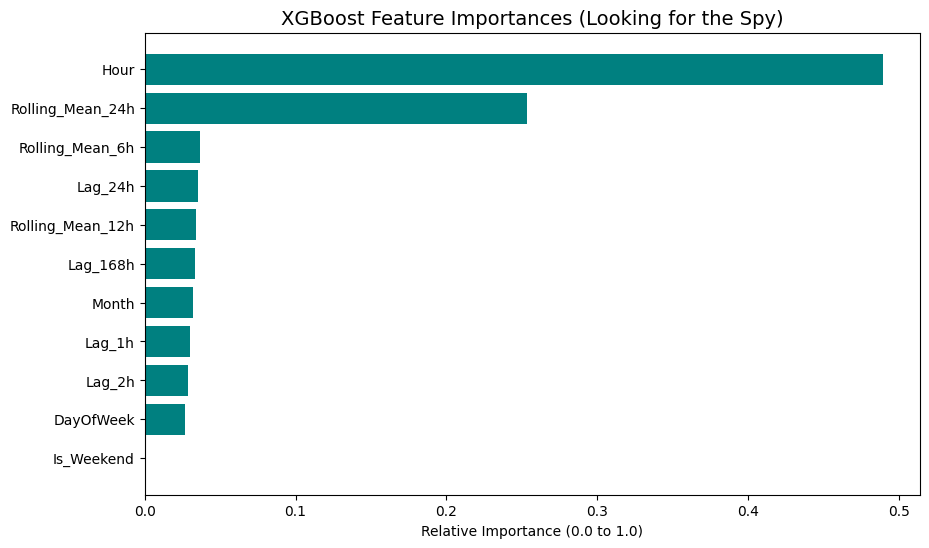

Datetime
2015-11-01 00:00:00     5.0
2015-11-01 01:00:00     5.0
2015-11-01 02:00:00     7.0
2015-11-01 03:00:00     2.0
2015-11-01 04:00:00     3.0
2015-11-01 05:00:00     4.0
2015-11-01 06:00:00     4.0
2015-11-01 07:00:00     3.0
2015-11-01 08:00:00     9.0
2015-11-01 09:00:00     5.0
2015-11-01 10:00:00     9.0
2015-11-01 11:00:00    11.0
2015-11-01 12:00:00     6.0
2015-11-01 13:00:00    10.0
2015-11-01 14:00:00     7.0
Name: Arrivals, dtype: float64


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Ask XGBoost exactly which columns it relied on
importances = xgb_model.feature_importances_
features = X_train.columns

# Sort them from least to most important
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('XGBoost Feature Importances (Looking for the Spy)', fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance (0.0 to 1.0)')
plt.show()

# Also, let's peek at the first 15 hours of the test set just to
# make sure the target variable isn't doing something bizarre.
print(y_test.head(15))

This cell uses Optuna for hyperparameter tuning of the CatBoost model to find the best parameters that minimize the Mean Absolute Error (MAE).

In [13]:
!pip install optuna -q
import optuna
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error

# 1. Define the objective function for Optuna to minimize
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 800),
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_seed': 42,
        'verbose': 0
    }

    # Train model on our clean chronological split
    model = CatBoostRegressor(**params)
    categorical_features = ['Hour', 'DayOfWeek', 'Month', 'Is_Weekend']
    model.fit(X_train, y_train, cat_features=categorical_features)

    # Predict on test data
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    return mae

# 2. Run the optimization study (10-15 trials is a good quick sweet spot for Colab)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=12)

print("\n--- OPTUNA TUNING COMPLETE ---")
print(f"Best Trial MAE: {study.best_value:.2f}")
print("Best Hyperparameters:", study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.9 MB/s eta 0:00:00


[I 2026-05-19 12:40:29,272] A new study created in memory with name: no-name-68bd975f-07f9-4ffe-9205-b1b13d7d9dbf
[I 2026-05-19 12:40:35,661] Trial 0 finished with value: 1.498930818404443 and parameters: {'iterations': 731, 'depth': 5, 'learning_rate': 0.0883727955443137, 'l2_leaf_reg': 1.4357405315178615}. Best is trial 0 with value: 1.498930818404443.
[I 2026-05-19 12:40:42,750] Trial 1 finished with value: 1.476489872641765 and parameters: {'iterations': 505, 'depth': 7, 'learning_rate': 0.01716079555154221, 'l2_leaf_reg': 0.021476848604997933}. Best is trial 1 with value: 1.476489872641765.
[I 2026-05-19 12:40:49,899] Trial 2 finished with value: 1.5018119411270106 and parameters: {'iterations': 400, 'depth': 8, 'learning_rate': 0.09944037464333941, 'l2_leaf_reg': 2.552975149294337}. Best is trial 1 with value: 1.476489872641765.
[I 2026-05-19 12:40:55,209] Trial 3 finished with value: 1.467721083976683 and parameters: {'iterations': 409, 'depth': 6, 'learning_rate': 0.02574425603


--- OPTUNA TUNING COMPLETE ---
Best Trial MAE: 1.47
Best Hyperparameters: {'iterations': 498, 'depth': 7, 'learning_rate': 0.027776583369995778, 'l2_leaf_reg': 0.016765695598873684}


This cell trains the CatBoost model with the best hyperparameters found by Optuna and saves the trained model as a pickle file.

In [14]:
import joblib

# Train the absolute best iteration of our forecaster
best_cb = CatBoostRegressor(**study.best_params, random_seed=42, verbose=0)
best_cb.fit(X_train, y_train, cat_features=['Hour', 'DayOfWeek', 'Month', 'Is_Weekend'])

# Save it directly to your folder path so Streamlit can pull it instantly
joblib.dump(best_cb, 'best_ed_forecaster.pkl')
print("Optimized production model successfully saved as 'best_ed_forecaster.pkl'!")

Optimized production model successfully saved as 'best_ed_forecaster.pkl'!


This cell trains a separate CatBoost model using only calendar-based features, evaluates its performance, and saves it as 'long_term_forecaster.pkl' for strategic analysis.

In [19]:
# --- BUILD THE LONG-TERM STRATEGIC MODEL ---
import joblib
from catboost import CatBoostRegressor

# 1. Select ONLY the calendar features
calendar_features = ['Hour', 'DayOfWeek', 'Month', 'Is_Weekend']
X_train_cal = X_train[calendar_features]
X_test_cal = X_test[calendar_features]

# 2. Train a new CatBoost model on just these features
print("Training Strategic Calendar Model...")
cb_cal_model = CatBoostRegressor(iterations=500, depth=6, learning_rate=0.05, random_seed=42, verbose=0)
cb_cal_model.fit(X_train_cal, y_train, cat_features=calendar_features)

# 3. Evaluate it so we know the trade-off
cb_cal_preds = cb_cal_model.predict(X_test_cal)
mae_cal = mean_absolute_error(y_test, cb_cal_preds)
print(f"Calendar-Only Model MAE: {mae_cal:.2f} patients/hour")

# 4. Save this model for our Dashboard!
joblib.dump(cb_cal_model, 'long_term_forecaster.pkl')
print("Saved as 'long_term_forecaster.pkl'")

Training Strategic Calendar Model...
Calendar-Only Model MAE: 2.38 patients/hour
Saved as 'long_term_forecaster.pkl'
